# Sales Prediction & Business Analytics — Exploration Notebook

This notebook walks through the same pipeline as `src/`, but interactively —
useful for EDA, sanity-checking the data, and inspecting the model.
For the production pipeline, use `run_pipeline.sh` / the `src/` modules directly.

## 1. Load and clean the data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_preprocessing import load_raw, clean_and_engineer

pd.set_option('display.max_columns', 30)
raw = load_raw()
df = clean_and_engineer(raw)
print(df.shape)
df.head()

[data_preprocessing] Loaded 20,000 rows from bundled sample dataset
(19680, 13)


,product_description,main_category,sub_category,ratings,total_sales,discount_price,actual_price,discount_percentage,price_band,description_length,description_word_count,is_high_rated,estimated_revenue
0,Bosch Lightweight Electricals 504S,home improvement,electricals,3.8,1121,6122.0,11310.0,45.87,Premium (₹5k-20k),34,4,0,6862762.0
1,Zebronics Heavy-Duty Keyboards & Mice 709Max,computers,keyboards & mice,3.6,780,9540.0,10693.0,10.78,Premium (₹5k-20k),44,6,0,7441200.0
2,24 Mantra Compact Organic Foods 303S,grocery & gourmet foods,organic foods,3.9,1289,1934.0,2199.0,12.05,Mid (₹1.5k-5k),36,6,0,2492926.0
3,Michelin Wireless Car Accessories 801Max,car & motorbike,car accessories,4.4,823,4169.0,5016.0,16.89,Premium (₹5k-20k),40,5,1,3431087.0
4,Redmi Wireless Smartphones 373Max,mobiles,smartphones,4.3,3118,10522.0,16439.0,35.99,Premium (₹5k-20k),33,4,1,32807596.0


## 2. Exploratory data analysis

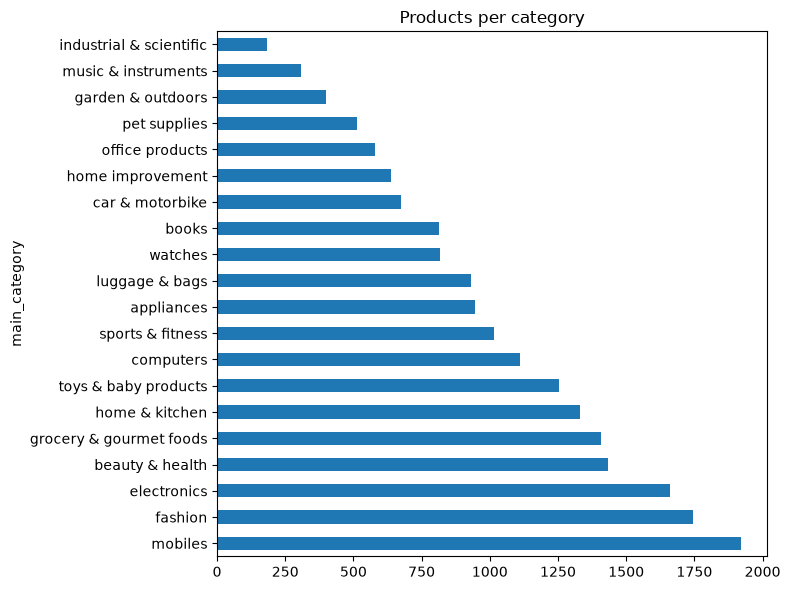

In [2]:
df['main_category'].value_counts().plot(kind='barh', figsize=(8,6), title='Products per category')
plt.tight_layout(); plt.show()

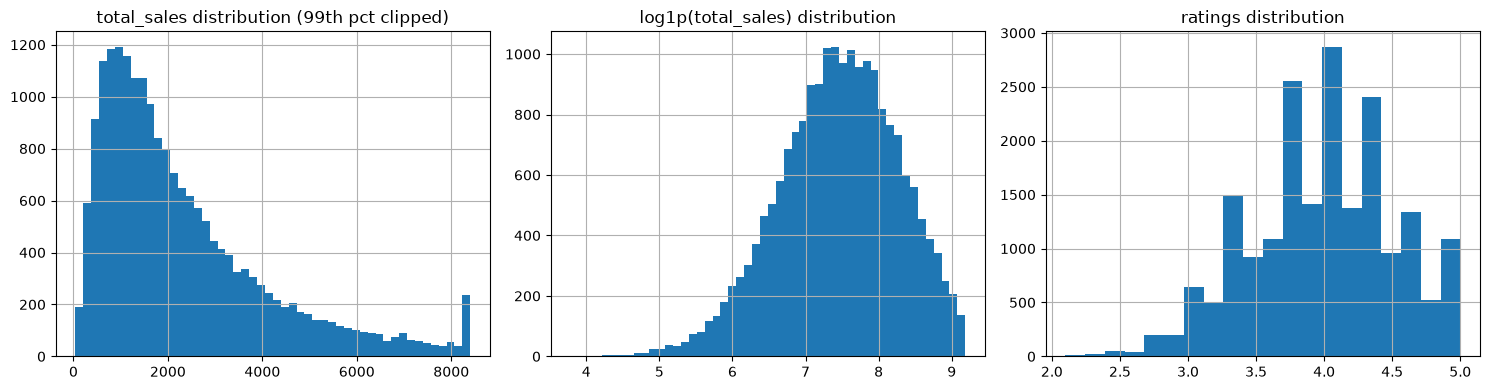

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df['total_sales'].clip(upper=df['total_sales'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('total_sales distribution (99th pct clipped)')

np.log1p(df['total_sales']).hist(bins=50, ax=axes[1])
axes[1].set_title('log1p(total_sales) distribution')

df['ratings'].hist(bins=20, ax=axes[2])
axes[2].set_title('ratings distribution')
plt.tight_layout(); plt.show()

In [4]:
corr_cols = ['actual_price', 'discount_price', 'discount_percentage', 'ratings', 'total_sales']
df[corr_cols].corr()

,actual_price,discount_price,discount_percentage,ratings,total_sales
actual_price,1.000000,0.983542,0.008222,0.015127,-0.119416
discount_price,0.983542,1.000000,-0.066148,0.014218,-0.130544
discount_percentage,0.008222,-0.066148,1.000000,-0.024031,0.181629
ratings,0.015127,0.014218,-0.024031,1.000000,0.502985
total_sales,-0.119416,-0.130544,0.181629,0.502985,1.000000


**Observation:** `ratings` typically shows the strongest positive correlation with
`total_sales`, while `actual_price` tends to correlate negatively — consistent with
intuition (higher-rated, cheaper-within-category products sell more). This matches
what `business_analytics.py` writes to `kpi_summary.csv` (`corr_price_vs_sales`,
`corr_rating_vs_sales`).

## 3. Feature pipeline + model comparison

In [5]:
from src.features import build_pipeline, ALL_FEATURE_COLS, TARGET_COL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

X = df[ALL_FEATURE_COLS]
y_log = np.log1p(df[TARGET_COL])
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

rows = []
for name, est in models.items():
    pipe = build_pipeline(est)
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    y_true, y_pred = np.expm1(y_test), np.clip(np.expm1(pred_log), 0, None)
    rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    })

pd.DataFrame(rows).sort_values('R2', ascending=False)

,model,MAE,RMSE,R2
2,XGBoost,627.836108,959.106770,0.700800
1,GradientBoosting,642.775969,1004.701734,0.671677
0,RandomForest,720.233119,1097.437556,0.608270


> For a properly hyperparameter-tuned comparison (RandomizedSearchCV across all
> three models), run `python -m src.train` from the project root instead — this
> notebook uses fixed, reasonable defaults just for quick interactive exploration.

## 4. Business analytics preview

In [6]:
from src.business_analytics import build_product_master, build_category_summary, build_abc_analysis

best_name = pd.DataFrame(rows).sort_values('R2', ascending=False).iloc[0]['model']
best_pipe = build_pipeline(models[best_name])
best_pipe.fit(X, y_log)  # refit on full data for the analytics preview

product_master = build_product_master(df, best_pipe, best_name)
category_summary = build_category_summary(product_master)
abc = build_abc_analysis(product_master)

category_summary.head(10)

,main_category,sub_category,product_count,avg_rating,avg_discount_pct,avg_actual_price,avg_discount_price,total_sales,avg_predicted_sales,total_estimated_revenue,revenue_share_pct,category_rank
0,mobiles,cases & covers,495,4.00,23.6,21730.46,16525.42,1857169,3438.399902,2.055509e+10,10.09,1
1,mobiles,smartphones,442,4.03,22.5,19921.66,15269.28,1642125,3448.800049,1.982787e+10,9.74,2
2,mobiles,power banks,492,3.95,22.5,20697.13,16001.36,1729617,3274.899902,1.936745e+10,9.51,3
3,mobiles,mobile accessories,492,3.97,22.3,19999.05,15318.60,1764481,3339.199951,1.856740e+10,9.12,4
4,computers,laptops,296,3.96,21.7,26506.30,20840.61,606301,1870.199951,9.102491e+09,4.47,5
5,computers,monitors,282,4.04,22.0,27043.87,21028.90,632615,2005.400024,8.796098e+09,4.32,6
6,computers,storage devices,274,3.99,23.3,22998.73,17609.24,633215,2074.199951,7.336361e+09,3.60,7
7,computers,keyboards & mice,258,3.97,22.5,23439.23,18218.21,541518,1979.400024,6.693064e+09,3.29,8
8,appliances,microwaves,226,4.11,23.3,25057.95,18995.51,452382,1845.400024,6.233880e+09,3.06,9
9,appliances,washing machines,250,3.95,24.0,24833.69,18987.55,440941,1579.500000,6.123515e+09,3.01,10


In [7]:
abc['abc_tier'].value_counts()

abc_tier
C - Long Tail              10458
B - Steady Contributors     5559
A - Top Revenue Drivers     3663
Name: count, dtype: int64

## 5. Next steps

- Run the full pipeline: `../run_pipeline.sh`
- Launch the app: `python ../app/app.py`
- Build the Tableau dashboard: see `../tableau/README.md`